## Overview
Previously, we had simulated traffic within NYC, with realistic pathing and traffic scenarios.
Having developed multiple simulations featuring varying levels of traffic (traffic=1, 2, 3), we 
will perform some light EDA on our simulation results.

## Setup

In [11]:
import pandas as pd
import numpy as np
import scipy.stats as scipy
import matplotlib.pyplot as pyplot
import seaborn

In [12]:
def perform(df_list, func): 
    for df in df_list:
        func(df)

In [13]:
# retrieve all datasets
t3 = pd.read_csv('data/all_density3.csv')
t2 = pd.read_csv('data/all_density2.csv')
t1 = pd.read_csv('data/all_density1.csv')
data = [t3, t2, t1]
# lets see all data statistics
perform(data, lambda df: print(df.info(), end="\n\n"))

<class 'pandas.DataFrame'>
RangeIndex: 18509 entries, 0 to 18508
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   vehicle_id     18509 non-null  str  
 1   total_seconds  18509 non-null  int64
dtypes: int64(1), str(1)
memory usage: 289.3 KB
None

<class 'pandas.DataFrame'>
RangeIndex: 13550 entries, 0 to 13549
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   vehicle_id     13550 non-null  str  
 1   total_seconds  13550 non-null  int64
dtypes: int64(1), str(1)
memory usage: 211.8 KB
None

<class 'pandas.DataFrame'>
RangeIndex: 6897 entries, 0 to 6896
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   vehicle_id     6897 non-null   str  
 1   total_seconds  6897 non-null   int64
dtypes: int64(1), str(1)
memory usage: 107.9 KB
None



## Data Wrangling and Feature Engineering

In [14]:
perform(data, display)

,vehicle_id,total_seconds
0,veh64,50
1,veh64.1,49
2,veh64.2,64
3,veh112,53
4,veh112.1,51
...,...,...
18504,veh6342.2,820
18505,veh6780.2,618
18506,veh7791.2,187
18507,veh7901.1,142


,vehicle_id,total_seconds
0,veh64,57
1,veh64.1,56
2,veh112,54
3,veh112.1,53
4,veh69,86
...,...,...
13545,veh6845,607
13546,veh7140,478
13547,veh7296,410
13548,veh7296.1,407


,vehicle_id,total_seconds
0,veh64,65
1,veh112,48
2,veh69,85
3,veh76,100
4,veh40,119
...,...,...
6892,veh7768,200
6893,veh7212,445
6894,veh7773,200
6895,veh7527,309


In [15]:
# create time_in_hour column
# since the first step is 0, we'll add one to all values
# then we will divide each by 3600
for df in data:
    df['total_seconds'] += 1
    df['total_hours'] = df['total_seconds'] / 3600
display(data[0])

,vehicle_id,total_seconds,total_hours
0,veh64,51,0.014167
1,veh64.1,50,0.013889
2,veh64.2,65,0.018056
3,veh112,54,0.015000
4,veh112.1,52,0.014444
...,...,...,...
18504,veh6342.2,821,0.228056
18505,veh6780.2,619,0.171944
18506,veh7791.2,188,0.052222
18507,veh7901.1,143,0.039722


## Statistical Analysis

In [16]:
# lets check statistics
perform(data, lambda df: print(df.describe(), end="\n\n"))

       total_seconds   total_hours
count   18509.000000  18509.000000
mean      476.633476      0.132398
std       298.649854      0.082958
min        32.000000      0.008889
25%       268.000000      0.074444
50%       412.000000      0.114444
75%       608.000000      0.168889
max      3217.000000      0.893611

       total_seconds   total_hours
count   13550.000000  13550.000000
mean      360.693358      0.100193
std       178.787889      0.049663
min        28.000000      0.007778
25%       231.000000      0.064167
50%       333.000000      0.092500
75%       461.000000      0.128056
max      1537.000000      0.426944

       total_seconds  total_hours
count    6897.000000  6897.000000
mean      311.351457     0.086487
std       136.659470     0.037961
min        33.000000     0.009167
25%       209.000000     0.058056
50%       297.000000     0.082500
75%       394.000000     0.109444
max      1054.000000     0.292778



[]

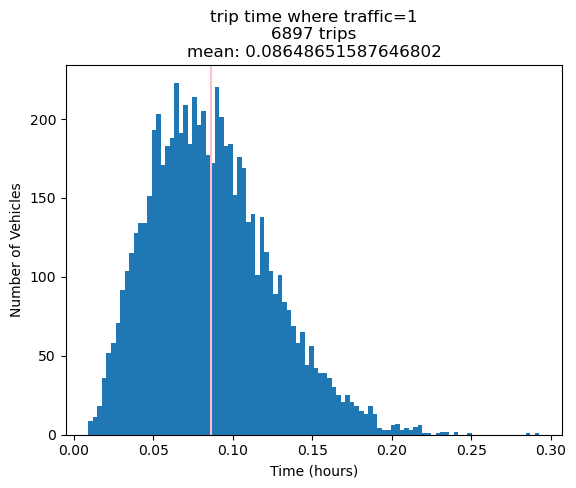

In [17]:
# lets plot for traffic level = 1
t1_time_mean = np.mean(t1.total_hours)
pyplot.hist(data=t1, x='total_hours', bins=100)
pyplot.title(f'trip time where traffic=1\n{len(t1)} trips\nmean: {t1_time_mean}')
pyplot.axvline(x=t1_time_mean).set_color('pink')
pyplot.ylabel('Number of Vehicles')
pyplot.xlabel('Time (hours)')
pyplot.plot()

[]

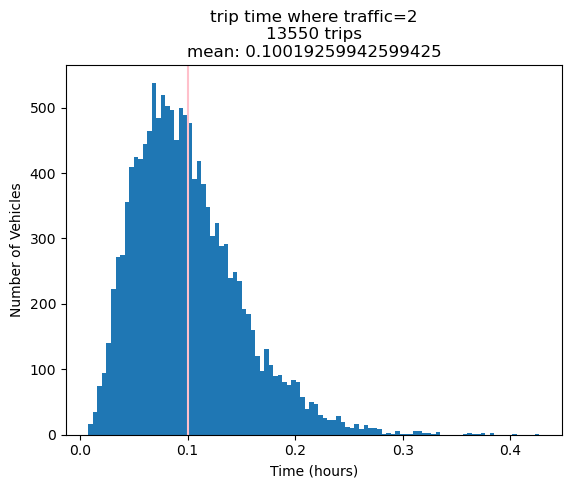

In [18]:
# lets plot for traffic level = 2
t2_time_mean = np.mean(t2.total_hours)
pyplot.hist(data=t2, x='total_hours', bins=100)
pyplot.title(f'trip time where traffic=2\n{len(t2)} trips\nmean: {t2_time_mean}')
pyplot.axvline(x=t2_time_mean).set_color('pink')
pyplot.ylabel('Number of Vehicles')
pyplot.xlabel('Time (hours)')
pyplot.plot()

[]

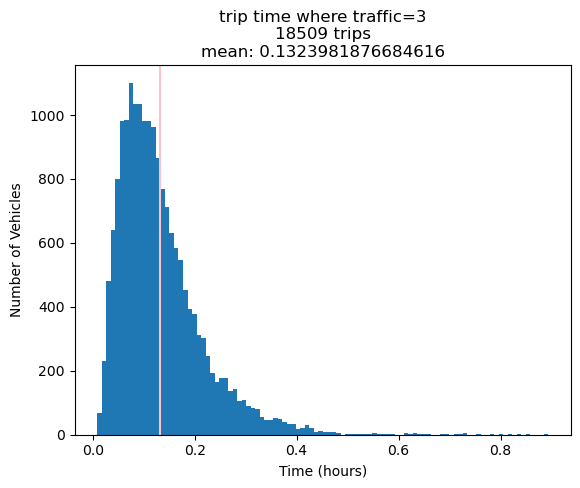

In [19]:
# lets plot for traffic level = 3
t3_time_mean = np.mean(t3.total_hours)
pyplot.hist(data=t3, x='total_hours', bins=100)
pyplot.title(f'trip time where traffic=3\n{len(t3)} trips\nmean: {t3_time_mean}')
pyplot.axvline(x=t3_time_mean).set_color('pink')
pyplot.ylabel('Number of Vehicles')
pyplot.xlabel('Time (hours)')
pyplot.plot()

## Conclusions
Overall, our traffic level does, naturally tend to affect the distribution and mean of the trip
times. It appears that our distribution becomes more skewed as traffic increases, and the mean 
follows.